<a href="https://colab.research.google.com/github/Krishna-Dhawangale/Resume-Screening-Machine-Learning-/blob/main/Resume_Screening(Random_Forest).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/ML_Data/AI_Resume_Screening.csv"
df=pd.read_csv(path)
df.head(5)

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [ ]:
df.shape

(1000, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [ ]:
df.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [ ]:
df.isnull().any().any()

np.True_

In [ ]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [ ]:
df[df.isnull().any(axis=1)]

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100
16,17,Megan Brown,"SQL, Python",10,PhD,NaN,Data Scientist,Hire,115364,2,100
17,18,Frances Davis MD,"Linux, Networking, Cybersecurity, Ethical Hacking",3,B.Tech,NaN,Cybersecurity Analyst,Hire,66379,6,80
18,19,Jonathon Pineda,"SQL, Python, Deep Learning",3,MBA,NaN,Data Scientist,Hire,112439,10,95
...,...,...,...,...,...,...,...,...,...,...,...
970,971,Chloe Blake,"C++, React, SQL",0,MBA,NaN,Software Engineer,Reject,45815,7,50
976,977,Louis Spencer,"Python, NLP",3,B.Sc,NaN,AI Researcher,Hire,95270,7,75
982,983,Kristin Ferguson,"SQL, C++, Java",6,MBA,NaN,Software Engineer,Hire,49261,1,80
986,987,Carolyn Little,"SQL, Deep Learning, Machine Learning",1,MBA,NaN,Data Scientist,Hire,44099,8,65


In [ ]:
X = df.drop(columns=['Recruiter Decision'])
y = df['Recruiter Decision']

In [ ]:
X.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,87441,9,100


In [ ]:
X = pd.get_dummies(X, dtype=int)

In [ ]:
X.shape

(1000, 1244)

In [ ]:
X.head(5)

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100),Name_Abigail Brock,Name_Abigail Watts,Name_Adam Hopkins,Name_Adam Tapia,Name_Adrian Marshall,...,Education_M.Tech,Education_MBA,Education_PhD,Certifications_AWS Certified,Certifications_Deep Learning Specialization,Certifications_Google ML,Job Role_AI Researcher,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer
0,1,10,104895,8,100,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,2,10,113002,1,100,0,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
2,3,1,71766,7,70,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
3,4,7,46848,0,95,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
4,5,4,87441,9,100,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1


In [ ]:
X.columns

Index(['Resume_ID', 'Experience (Years)', 'Salary Expectation ($)',
       'Projects Count', 'AI Score (0-100)', 'Name_Abigail Brock',
       'Name_Abigail Watts', 'Name_Adam Hopkins', 'Name_Adam Tapia',
       'Name_Adrian Marshall',
       ...
       'Education_M.Tech', 'Education_MBA', 'Education_PhD',
       'Certifications_AWS Certified',
       'Certifications_Deep Learning Specialization',
       'Certifications_Google ML', 'Job Role_AI Researcher',
       'Job Role_Cybersecurity Analyst', 'Job Role_Data Scientist',
       'Job Role_Software Engineer'],
      dtype='object', length=1244)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y,train_size=0.7,test_size=0.3,random_state=42)

In [ ]:
X_train.shape,X_test.shape

((700, 1244), (300, 1244))

In [ ]:
from sklearn.model_selection import train_test_split
# Splitting the data with test_size=0.3
X_train_0_3, X_test_0_3, y_train_0_3, y_test_0_3 = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Training the model with test_size=0.3
rf_classifier_0_3 = RandomForestClassifier(n_estimators=100, n_jobs=-1, max_depth=5, oob_score=True, random_state=42)
rf_classifier_0_3.fit(X_train_0_3, y_train_0_3)

# Making predictions with test_size=0.3
y_pred_0_3 = rf_classifier_0_3.predict(X_test_0_3)

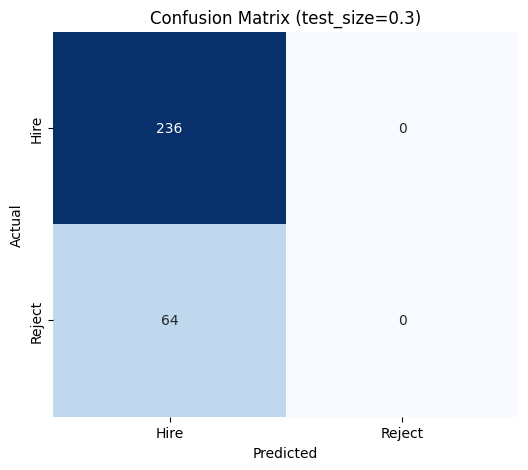

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plotting the Confusion Matrix for test_size=0.3
cm_0_3 = confusion_matrix(y_test_0_3, y_pred_0_3)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_0_3, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Hire', 'Reject'], yticklabels=['Hire', 'Reject'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (test_size=0.3)')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, n_jobs=-1, max_depth=5, oob_score=True, random_state=42)
rf_classifier.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, oob_score=True, random_state=42)

In [ ]:
# prediction
y_pred = rf_classifier.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [ ]:
print('Confusion Matrix')
cm=confusion_matrix(y_pred, y_test)
print(confusion_matrix(y_pred,y_test))

Confusion Matrix
[[196  54]
 [  0   0]]


In [ ]:
print('Accuracy Score')
print(accuracy_score(y_pred,y_test))

Accuracy Score
0.784


In [ ]:
rf_classifier.oob_score_

0.8233333333333334

In [ ]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

params = {
    'max_depth':[2,3,5,10,20],
    'min_samples_leaf':[5,10,20,50,100,200],
    'n_estimators': [10,25,30,50,100,200]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=rf, param_grid=params, cv=4, n_jobs=-1, verbose=1, scoring='accuracy')
grid_search.fit(X_train,y_train)

Fitting 4 folds for each of 180 candidates, totalling 720 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [5, 10, 20, 50, 100, 200],
                         'n_estimators': [10, 25, 30, 50, 100, 200]},
             scoring='accuracy', verbose=1)

In [ ]:
print('Best parameters found by GridSearchCV:')
print(grid_search.best_params_)

Best parameters found by GridSearchCV:
{'max_depth': 2, 'min_samples_leaf': 5, 'n_estimators': 10}


In [ ]:
grid_search.best_score_

np.float64(0.8200000000000001)

In [ ]:
print('Classification Report')
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

        Hire       0.78      1.00      0.88       196
      Reject       0.00      0.00      0.00        54

    accuracy                           0.78       250
   macro avg       0.39      0.50      0.44       250
weighted avg       0.61      0.78      0.69       250



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape,X_test.shape

((800, 1244), (200, 1244))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, n_jobs=-1, max_depth=5, oob_score=True, random_state=42)
rf_classifier.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, oob_score=True, random_state=42)

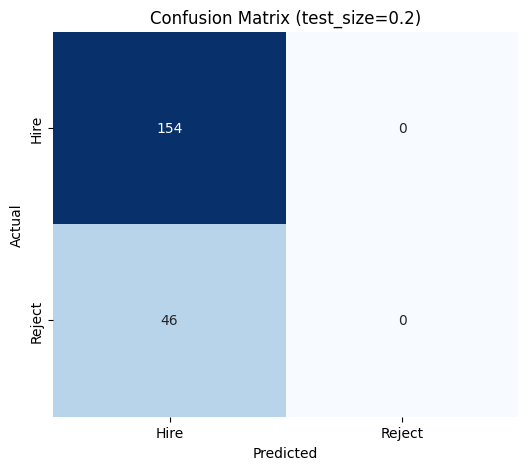

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plotting the Confusion Matrix for test_size=0.2
cm_0_2 = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_0_2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Hire', 'Reject'], yticklabels=['Hire', 'Reject'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (test_size=0.2)')
plt.show()

In [ ]:
# prediction
y_pred = rf_classifier.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [ ]:
print('Confusion Matrix')
cm=confusion_matrix(y_pred, y_test)
print(confusion_matrix(y_pred,y_test))

Confusion Matrix
[[154  46]
 [  0   0]]


In [ ]:
print('Accuracy Score')
print(accuracy_score(y_pred,y_test))

Accuracy Score
0.77


In [ ]:
rf_classifier.oob_score_

0.8225

In [ ]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

params = {
    'max_depth':[2,3,5,10,20],
    'min_samples_leaf':[5,10,20,50,100,200],
    'n_estimators': [10,25,30,50,100,200]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=rf, param_grid=params, cv=4, n_jobs=-1, verbose=1, scoring='accuracy')
grid_search.fit(X_train,y_train)

Fitting 4 folds for each of 180 candidates, totalling 720 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [5, 10, 20, 50, 100, 200],
                         'n_estimators': [10, 25, 30, 50, 100, 200]},
             scoring='accuracy', verbose=1)

In [ ]:
print('Classification Report')
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

        Hire       0.77      1.00      0.87       154
      Reject       0.00      0.00      0.00        46

    accuracy                           0.77       200
   macro avg       0.39      0.50      0.44       200
weighted avg       0.59      0.77      0.67       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
